# Dropout Prediction: Model Training (Without Data Leakage)

This notebook:
1. Loads the prepared dataset
2. **Excludes data leakage features** (has_unregistration, date_unregistration, days_until_unregistration)
3. Trains multiple classification models
4. Evaluates models using various metrics
5. Selects the best performing model
6. Saves the best model for deployment

## Important Note on Data Leakage

The original model training included features that directly encode information about the target variable:
- `has_unregistration`: Binary indicator of whether student has unregistered
- `date_unregistration`: The actual unregistration date
- `days_until_unregistration`: Days until unregistration

These features represent **data leakage** because:
- They are only available **after** a student has dropped out
- They directly indicate the target variable (dropout)
- They lead to artificially inflated performance (99%+ accuracy)

**This notebook trains models WITHOUT these leakage features** to get realistic performance metrics that would be achievable in a real-world early warning system.

See `data-leakage-analysis.md` for detailed analysis.


## 1. Setup and Imports


In [1]:
# Install required packages
!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost joblib



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib
import json
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('ggplot')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Load Prepared Dataset


In [3]:
# Load the prepared dataset
data_file = 'prepared_data/dropout_prediction_prepared.csv'

if not os.path.exists(data_file):
    raise FileNotFoundError(f"Could not find prepared dataset at: {data_file}")

df = pd.read_csv(data_file)
print(f"✓ Loaded dataset: {df.shape}")
print(f"  Columns: {df.shape[1]}")
print(f"  Samples: {df.shape[0]:,}")

# Display first few rows
df.head()


✓ Loaded dataset: (32593, 40)
  Columns: 40
  Samples: 32,593


,code_module,code_presentation,id_student,num_of_prev_attempts,studied_credits,final_result,is_dropout,date_registration,date_unregistration,registered_early,registered_late,days_before_start,days_after_start,has_unregistration,days_until_unregistration,module_presentation_length,avg_assessment_score,min_assessment_score,max_assessment_score,num_assessments,first_assessment_day,last_assessment_day,num_banked_assessments,weighted_avg_score,total_vle_clicks,avg_daily_clicks,max_daily_clicks,vle_interaction_days,first_vle_day,last_vle_day,vle_engagement_rate,presentation_year,has_disability,gender_encoded,region_encoded,highest_education_encoded,imd_band_encoded,age_band_encoded,disability_encoded,presentation_semester_encoded
0,AAA,2013J,11391,0,240,Pass,0,-159.0,0.0,1,0,159.0,0.0,0,0.0,268,82.0,78.0,85.0,5.0,18.0,212.0,0.0,82.40,934.0,4.765306,76.0,196.0,-5.0,253.0,4.765306,2013,0,1,0,1,9,2,0,1
1,AAA,2013J,28400,0,60,Pass,0,-53.0,0.0,1,0,53.0,0.0,0,0.0,268,66.4,60.0,70.0,5.0,22.0,212.0,0.0,65.40,1435.0,3.337209,23.0,430.0,-10.0,239.0,3.337209,2013,0,0,6,1,2,1,0,1
2,AAA,2013J,30268,0,60,Withdrawn,1,-92.0,12.0,1,0,92.0,0.0,1,12.0,268,76.0,0.0,0.0,0.0,0.0,0.0,0.0,72.96,281.0,3.697368,23.0,76.0,-10.0,12.0,3.697368,2013,1,0,5,0,3,1,1,1
3,AAA,2013J,31604,0,60,Pass,0,-52.0,0.0,1,0,52.0,0.0,0,0.0,268,76.0,71.0,88.0,5.0,17.0,213.0,0.0,76.30,2158.0,3.254902,22.0,663.0,-10.0,264.0,3.254902,2013,0,0,7,0,5,1,0,1
4,AAA,2013J,32885,0,60,Pass,0,-176.0,0.0,1,0,176.0,0.0,0,0.0,268,54.4,30.0,75.0,5.0,26.0,222.0,0.0,55.00,1034.0,2.937500,22.0,352.0,-10.0,247.0,2.937500,2013,0,0,11,2,5,0,0,1


In [4]:
# Check target variable distribution
print("=" * 60)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 60)
if 'is_dropout' in df.columns:
    target_counts = df['is_dropout'].value_counts()
    target_pct = df['is_dropout'].value_counts(normalize=True) * 100
    
    target_df = pd.DataFrame({
        'Count': target_counts,
        'Percentage': target_pct
    })
    target_df.index = ['Not Dropout (0)', 'Dropout (1)']
    print(target_df)
    print(f"\nDropout rate: {df['is_dropout'].mean() * 100:.2f}%")
else:
    print("Warning: 'is_dropout' column not found. Checking available columns...")
    print(df.columns.tolist())


TARGET VARIABLE DISTRIBUTION
                 Count  Percentage
Not Dropout (0)  22437   68.839935
Dropout (1)      10156   31.160065

Dropout rate: 31.16%


## 3. Prepare Features and Target (Excluding Data Leakage Features)


In [5]:
# Separate features and target
# Exclude identifier columns, target, AND data leakage features
exclude_cols = [
    'code_module', 'code_presentation', 'id_student', 'final_result', 'is_dropout',
    # Data leakage features - these encode information about the target variable
    'has_unregistration',      # Direct indicator of dropout
    'date_unregistration',     # Unregistration date (only available after dropout)
    'days_until_unregistration'  # Derived from unregistration date
]

feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols].copy()
y = df['is_dropout'].copy()

print("=" * 60)
print("FEATURE PREPARATION (WITHOUT DATA LEAKAGE)")
print("=" * 60)
print(f"\nExcluded leakage features:")
print("  - has_unregistration")
print("  - date_unregistration")
print("  - days_until_unregistration")
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nNumber of features: {len(feature_cols)}")
print(f"\nFeature columns:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")


FEATURE PREPARATION (WITHOUT DATA LEAKAGE)

Excluded leakage features:
  - has_unregistration
  - date_unregistration
  - days_until_unregistration

Features shape: (32593, 32)
Target shape: (32593,)

Number of features: 32

Feature columns:
   1. num_of_prev_attempts
   2. studied_credits
   3. date_registration
   4. registered_early
   5. registered_late
   6. days_before_start
   7. days_after_start
   8. module_presentation_length
   9. avg_assessment_score
  10. min_assessment_score
  11. max_assessment_score
  12. num_assessments
  13. first_assessment_day
  14. last_assessment_day
  15. num_banked_assessments
  16. weighted_avg_score
  17. total_vle_clicks
  18. avg_daily_clicks
  19. max_daily_clicks
  20. vle_interaction_days
  21. first_vle_day
  22. last_vle_day
  23. vle_engagement_rate
  24. presentation_year
  25. has_disability
  26. gender_encoded
  27. region_encoded
  28. highest_education_encoded
  29. imd_band_encoded
  30. age_band_encoded
  31. disability_encoded

In [6]:
# Split into train/validation/test sets (same split as preparation)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.2,
    random_state=42,
    stratify=y_temp
)

print("=" * 60)
print("DATASET SPLITS")
print("=" * 60)
print(f"Training set:   {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTotal:          {len(X):,} samples")


DATASET SPLITS
Training set:   20,859 samples (64.0%)
Validation set: 5,215 samples (16.0%)
Test set:       6,519 samples (20.0%)

Total:          32,593 samples


In [7]:
# Scale features for models that require scaling
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("✓ Features scaled (StandardScaler)")


✓ Features scaled (StandardScaler)


## 4. Define Models to Train


In [8]:
# Define models to train
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42, learning_rate=0.1),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(random_state=42, probability=True, class_weight='balanced'),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

print(f"Defined {len(models)} models to train:")
for name in models.keys():
    print(f"  - {name}")


Defined 8 models to train:
  - Logistic Regression
  - Random Forest
  - Gradient Boosting
  - XGBoost
  - AdaBoost
  - SVM
  - K-Nearest Neighbors
  - Naive Bayes


## 5. Train and Evaluate Models


In [9]:
# Dictionary to store results
results = {}
trained_models = {}

print("=" * 60)
print("TRAINING MODELS (WITHOUT DATA LEAKAGE FEATURES)")
print("=" * 60)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Determine if model needs scaled data
    needs_scaling = name in ['Logistic Regression', 'SVM', 'K-Nearest Neighbors', 'Naive Bayes']
    
    if needs_scaling:
        X_train_use = X_train_scaled
        X_val_use = X_val_scaled
    else:
        X_train_use = X_train
        X_val_use = X_val
    
    # Train model
    model.fit(X_train_use, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train_use)
    y_val_pred = model.predict(X_val_use)
    
    # Get prediction probabilities for ROC-AUC
    y_train_proba = model.predict_proba(X_train_use)[:, 1]
    y_val_proba = model.predict_proba(X_val_use)[:, 1]
    
    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    val_accuracy = accuracy_score(y_val, y_val_pred)
    
    train_precision = precision_score(y_train, y_train_pred, zero_division=0)
    val_precision = precision_score(y_val, y_val_pred, zero_division=0)
    
    train_recall = recall_score(y_train, y_train_pred)
    val_recall = recall_score(y_val, y_val_pred)
    
    train_f1 = f1_score(y_train, y_train_pred)
    val_f1 = f1_score(y_val, y_val_pred)
    
    train_roc_auc = roc_auc_score(y_train, y_train_proba)
    val_roc_auc = roc_auc_score(y_val, y_val_proba)
    
    # Store results
    results[name] = {
        'train_accuracy': train_accuracy,
        'val_accuracy': val_accuracy,
        'train_precision': train_precision,
        'val_precision': val_precision,
        'train_recall': train_recall,
        'val_recall': val_recall,
        'train_f1': train_f1,
        'val_f1': val_f1,
        'train_roc_auc': train_roc_auc,
        'val_roc_auc': val_roc_auc,
        'needs_scaling': needs_scaling
    }
    
    trained_models[name] = model
    
    print(f"  ✓ Training Accuracy: {train_accuracy:.4f}")
    print(f"  ✓ Validation Accuracy: {val_accuracy:.4f}")
    print(f"  ✓ Validation F1: {val_f1:.4f}")
    print(f"  ✓ Validation ROC-AUC: {val_roc_auc:.4f}")

print("\n" + "=" * 60)
print("ALL MODELS TRAINED SUCCESSFULLY")
print("=" * 60)


TRAINING MODELS (WITHOUT DATA LEAKAGE FEATURES)

Training Logistic Regression...
  ✓ Training Accuracy: 0.8581
  ✓ Validation Accuracy: 0.8525
  ✓ Validation F1: 0.7893
  ✓ Validation ROC-AUC: 0.9313

Training Random Forest...
  ✓ Training Accuracy: 1.0000
  ✓ Validation Accuracy: 0.8665
  ✓ Validation F1: 0.7915
  ✓ Validation ROC-AUC: 0.9459

Training Gradient Boosting...
  ✓ Training Accuracy: 0.8830
  ✓ Validation Accuracy: 0.8694
  ✓ Validation F1: 0.8054
  ✓ Validation ROC-AUC: 0.9482

Training XGBoost...
  ✓ Training Accuracy: 0.9654
  ✓ Validation Accuracy: 0.8717
  ✓ Validation F1: 0.8021
  ✓ Validation ROC-AUC: 0.9470

Training AdaBoost...
  ✓ Training Accuracy: 0.8603
  ✓ Validation Accuracy: 0.8591
  ✓ Validation F1: 0.7887
  ✓ Validation ROC-AUC: 0.9388

Training SVM...
  ✓ Training Accuracy: 0.8685
  ✓ Validation Accuracy: 0.8539
  ✓ Validation F1: 0.8003
  ✓ Validation ROC-AUC: 0.9265

Training K-Nearest Neighbors...
  ✓ Training Accuracy: 0.8919
  ✓ Validation Accuracy:

In [10]:
# Create comparison dataframe
comparison_data = []
for name, metrics in results.items():
    comparison_data.append({
        'Model': name,
        'Val Accuracy': metrics['val_accuracy'],
        'Val Precision': metrics['val_precision'],
        'Val Recall': metrics['val_recall'],
        'Val F1': metrics['val_f1'],
        'Val ROC-AUC': metrics['val_roc_auc'],
        'Train Accuracy': metrics['train_accuracy'],
        'Train F1': metrics['train_f1']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Val F1', ascending=False)

print("=" * 60)
print("MODEL COMPARISON (Sorted by Validation F1 Score)")
print("=" * 60)
print(comparison_df.to_string(index=False))


MODEL COMPARISON (Sorted by Validation F1 Score)
              Model  Val Accuracy  Val Precision  Val Recall   Val F1  Val ROC-AUC  Train Accuracy  Train F1
  Gradient Boosting      0.869415       0.751868    0.867077 0.805373     0.948225        0.883024  0.824713
            XGBoost      0.871716       0.772210    0.834462 0.802130     0.947001        0.965387  0.945966
                SVM      0.853883       0.696942    0.939692 0.800314     0.926462        0.868450  0.820160
      Random Forest      0.866539       0.771162    0.812923 0.791492     0.945879        0.999952  0.999923
Logistic Regression      0.852541       0.711462    0.886154 0.789257     0.931271        0.858095  0.796171
           AdaBoost      0.859060       0.740022    0.844308 0.788732     0.938783        0.860348  0.790597
        Naive Bayes      0.841611       0.701057    0.857231 0.771318     0.912228        0.845726  0.775999
K-Nearest Neighbors      0.841994       0.741410    0.756923 0.749086     0.903

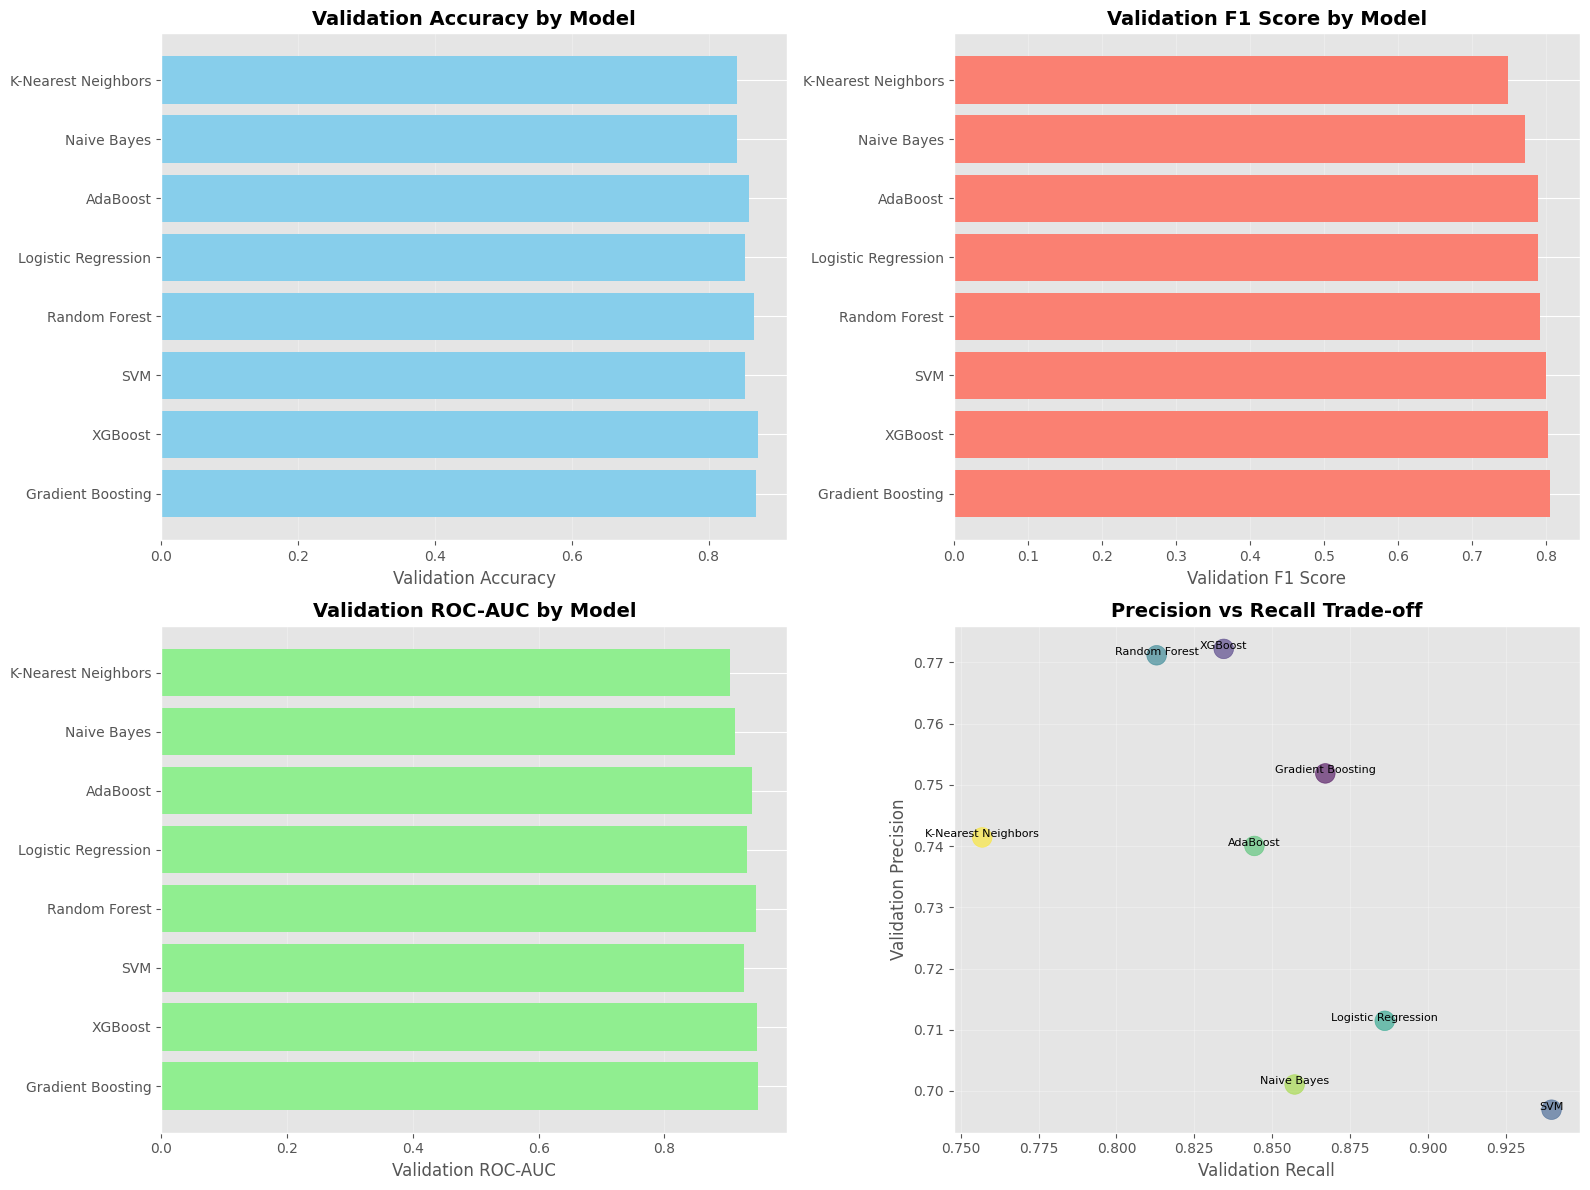

In [11]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Validation Accuracy
axes[0, 0].barh(comparison_df['Model'], comparison_df['Val Accuracy'], color='skyblue')
axes[0, 0].set_xlabel('Validation Accuracy', fontsize=12)
axes[0, 0].set_title('Validation Accuracy by Model', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Validation F1 Score
axes[0, 1].barh(comparison_df['Model'], comparison_df['Val F1'], color='salmon')
axes[0, 1].set_xlabel('Validation F1 Score', fontsize=12)
axes[0, 1].set_title('Validation F1 Score by Model', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# Validation ROC-AUC
axes[1, 0].barh(comparison_df['Model'], comparison_df['Val ROC-AUC'], color='lightgreen')
axes[1, 0].set_xlabel('Validation ROC-AUC', fontsize=12)
axes[1, 0].set_title('Validation ROC-AUC by Model', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# Validation Precision vs Recall
axes[1, 1].scatter(comparison_df['Val Recall'], comparison_df['Val Precision'], 
                   s=200, alpha=0.6, c=range(len(comparison_df)), cmap='viridis')
for i, model in enumerate(comparison_df['Model']):
    axes[1, 1].annotate(model, (comparison_df['Val Recall'].iloc[i], 
                             comparison_df['Val Precision'].iloc[i]),
                       fontsize=8, ha='center')
axes[1, 1].set_xlabel('Validation Recall', fontsize=12)
axes[1, 1].set_ylabel('Validation Precision', fontsize=12)
axes[1, 1].set_title('Precision vs Recall Trade-off', fontsize=14, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Select Best Model


In [12]:
# Select best model based on validation F1 score (balanced metric)
# You can change this to use ROC-AUC or other metrics
best_model_name = comparison_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
best_metrics = results[best_model_name]

print("=" * 60)
print(f"BEST MODEL: {best_model_name}")
print("=" * 60)
print(f"\nValidation Metrics:")
print(f"  Accuracy:  {best_metrics['val_accuracy']:.4f}")
print(f"  Precision: {best_metrics['val_precision']:.4f}")
print(f"  Recall:    {best_metrics['val_recall']:.4f}")
print(f"  F1 Score:  {best_metrics['val_f1']:.4f}")
print(f"  ROC-AUC:   {best_metrics['val_roc_auc']:.4f}")


BEST MODEL: Gradient Boosting

Validation Metrics:
  Accuracy:  0.8694
  Precision: 0.7519
  Recall:    0.8671
  F1 Score:  0.8054
  ROC-AUC:   0.9482


## 8. Evaluate Best Model on Test Set


In [13]:
# Evaluate best model on test set
needs_scaling = best_metrics['needs_scaling']

if needs_scaling:
    X_test_use = X_test_scaled
else:
    X_test_use = X_test

# Make predictions on test set
y_test_pred = best_model.predict(X_test_use)
y_test_proba = best_model.predict_proba(X_test_use)[:, 1]

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_proba)

print("=" * 60)
print(f"BEST MODEL TEST SET EVALUATION: {best_model_name}")
print("=" * 60)
print(f"\nTest Metrics:")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1 Score:  {test_f1:.4f}")
print(f"  ROC-AUC:   {test_roc_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {cm[0, 0]}")
print(f"  False Positives: {cm[0, 1]}")
print(f"  False Negatives: {cm[1, 0]}")
print(f"  True Positives:  {cm[1, 1]}")

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Not Dropout', 'Dropout']))


BEST MODEL TEST SET EVALUATION: Gradient Boosting

Test Metrics:
  Accuracy:  0.8773
  Precision: 0.7734
  Recall:    0.8572
  F1 Score:  0.8132
  ROC-AUC:   0.9502

Confusion Matrix:
  True Negatives:  3978
  False Positives: 510
  False Negatives: 290
  True Positives:  1741

Classification Report:
              precision    recall  f1-score   support

 Not Dropout       0.93      0.89      0.91      4488
     Dropout       0.77      0.86      0.81      2031

    accuracy                           0.88      6519
   macro avg       0.85      0.87      0.86      6519
weighted avg       0.88      0.88      0.88      6519



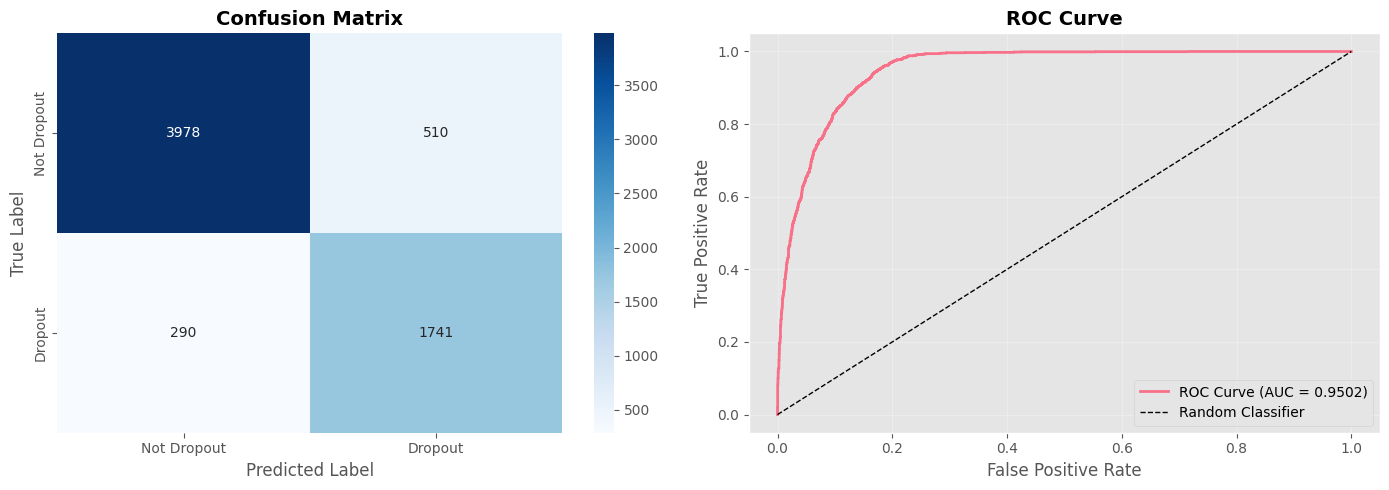

In [14]:
# Visualize confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Dropout', 'Dropout'],
            yticklabels=['Not Dropout', 'Dropout'])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
axes[1].plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {test_roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Feature Importance (if available)


TOP 20 MOST IMPORTANT FEATURES (Gradient Boosting)
(Note: Data leakage features excluded)
                   feature  importance
              last_vle_day    0.814128
       last_assessment_day    0.074922
      vle_interaction_days    0.020757
           studied_credits    0.017059
      max_assessment_score    0.016058
module_presentation_length    0.008762
             first_vle_day    0.008234
      first_assessment_day    0.005053
         days_before_start    0.003558
           num_assessments    0.003454
         date_registration    0.003452
      min_assessment_score    0.003386
         presentation_year    0.002802
          total_vle_clicks    0.002683
        weighted_avg_score    0.002551
            region_encoded    0.002077
      avg_assessment_score    0.001927
      num_of_prev_attempts    0.001911
       vle_engagement_rate    0.001448
 highest_education_encoded    0.001302


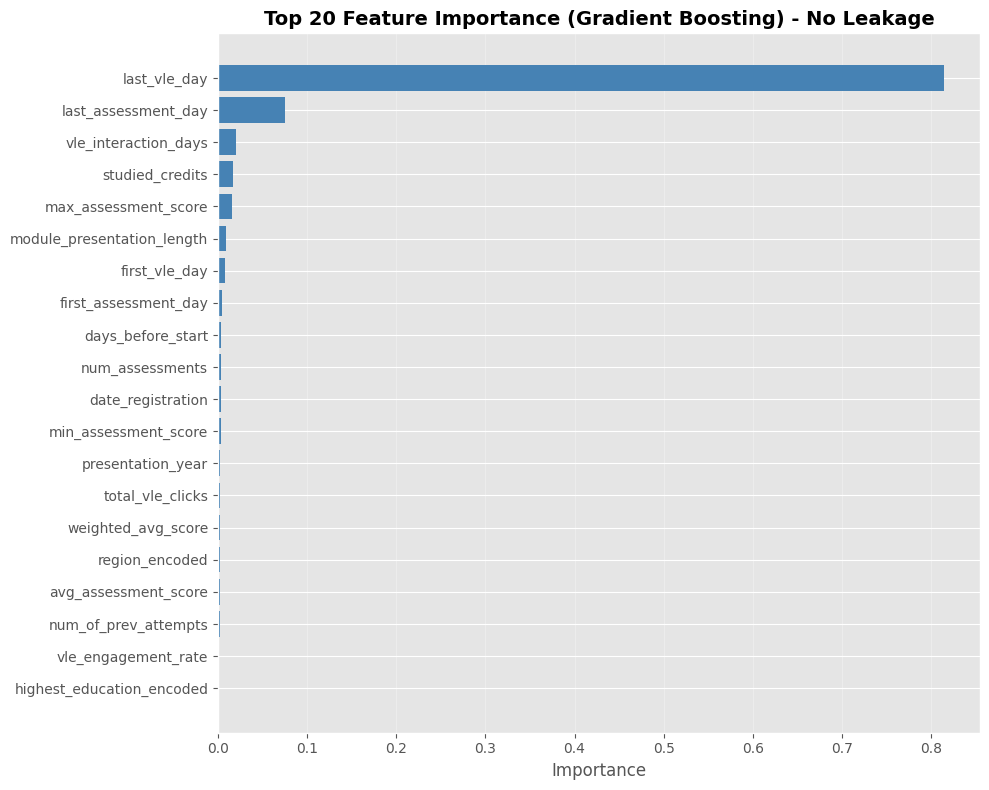

In [15]:
# Get feature importance if the model supports it
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("=" * 60)
    print(f"TOP 20 MOST IMPORTANT FEATURES ({best_model_name})")
    print("=" * 60)
    print("(Note: Data leakage features excluded)")
    print(feature_importance.head(20).to_string(index=False))
    
    # Visualize top features
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(20)
    plt.barh(range(len(top_features)), top_features['importance'], color='steelblue')
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importance', fontsize=12)
    plt.title(f'Top 20 Feature Importance ({best_model_name}) - No Leakage', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    # For linear models, use coefficients
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'coefficient': best_model.coef_[0]
    }).sort_values('coefficient', key=abs, ascending=False)
    
    print("=" * 60)
    print(f"TOP 20 MOST IMPORTANT FEATURES ({best_model_name} - Coefficients)")
    print("=" * 60)
    print("(Note: Data leakage features excluded)")
    print(feature_importance.head(20).to_string(index=False))
    
    # Visualize top features
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(20)
    colors = ['red' if x < 0 else 'green' for x in top_features['coefficient']]
    plt.barh(range(len(top_features)), top_features['coefficient'], color=colors)
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Coefficient', fontsize=12)
    plt.title(f'Top 20 Feature Coefficients ({best_model_name}) - No Leakage', fontsize=14, fontweight='bold')
    plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"Model {best_model_name} does not support feature importance extraction.")


In [16]:
# Create models directory
models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

# Save the best model (with suffix to indicate no leakage)
model_file = os.path.join(models_dir, 'best_dropout_model_no_leakage.pkl')
joblib.dump(best_model, model_file)
print(f"✓ Saved best model to: {model_file}")

# Save the scaler if needed
if best_metrics['needs_scaling']:
    scaler_file = os.path.join(models_dir, 'scaler_no_leakage.pkl')
    joblib.dump(scaler, scaler_file)
    print(f"✓ Saved scaler to: {scaler_file}")

# Save model metadata
metadata = {
    'model_name': best_model_name,
    'model_type': type(best_model).__name__,
    'needs_scaling': best_metrics['needs_scaling'],
    'feature_columns': feature_cols,
    'excluded_leakage_features': ['has_unregistration', 'date_unregistration', 'days_until_unregistration'],
    'test_accuracy': float(test_accuracy),
    'test_precision': float(test_precision),
    'test_recall': float(test_recall),
    'test_f1': float(test_f1),
    'test_roc_auc': float(test_roc_auc),
    'val_accuracy': float(best_metrics['val_accuracy']),
    'val_f1': float(best_metrics['val_f1']),
    'val_roc_auc': float(best_metrics['val_roc_auc'])
}

metadata_file = os.path.join(models_dir, 'model_metadata_no_leakage.json')
with open(metadata_file, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Saved model metadata to: {metadata_file}")

# Save comparison results
comparison_file = os.path.join(models_dir, 'model_comparison_no_leakage.csv')
comparison_df.to_csv(comparison_file, index=False)
print(f"✓ Saved model comparison to: {comparison_file}")

print(f"\n✓ All files saved successfully!")


✓ Saved best model to: models/best_dropout_model_no_leakage.pkl
✓ Saved model metadata to: models/model_metadata_no_leakage.json
✓ Saved model comparison to: models/model_comparison_no_leakage.csv

✓ All files saved successfully!


## 10. Model Training Without last_vle_day and last_assessment_day

In this section, we exclude `last_vle_day` and `last_assessment_day` features to analyze:
1. How model performance changes when these highly important features are removed
2. Which other features become more important
3. Whether the model can still achieve good performance without these temporal features

These features might encode information about student engagement near the end of the course, which could be considered somewhat predictive but potentially less actionable for early intervention.


In [17]:
# Prepare features excluding last_vle_day and last_assessment_day
# Start with original exclude_cols and add the two additional features
exclude_cols_extended = exclude_cols + ['last_vle_day', 'last_assessment_day']

feature_cols_reduced = [col for col in df.columns if col not in exclude_cols_extended]

X_reduced = df[feature_cols_reduced].copy()
y_reduced = df['is_dropout'].copy()

print("=" * 60)
print("FEATURE PREPARATION (WITHOUT last_vle_day AND last_assessment_day)")
print("=" * 60)
print(f"\nExcluded features:")
print("  - has_unregistration (data leakage)")
print("  - date_unregistration (data leakage)")
print("  - days_until_unregistration (data leakage)")
print("  - last_vle_day (temporal feature)")
print("  - last_assessment_day (temporal feature)")
print(f"\nOriginal features: {len(feature_cols)}")
print(f"Reduced features: {len(feature_cols_reduced)}")
print(f"Features removed: {len(feature_cols) - len(feature_cols_reduced)}")
print(f"\nFeatures shape: {X_reduced.shape}")
print(f"Target shape: {y_reduced.shape}")
print(f"\nRemoved feature columns:")
for col in ['last_vle_day', 'last_assessment_day']:
    if col in feature_cols:
        print(f"  - {col}")


FEATURE PREPARATION (WITHOUT last_vle_day AND last_assessment_day)

Excluded features:
  - has_unregistration (data leakage)
  - date_unregistration (data leakage)
  - days_until_unregistration (data leakage)
  - last_vle_day (temporal feature)
  - last_assessment_day (temporal feature)

Original features: 32
Reduced features: 30
Features removed: 2

Features shape: (32593, 30)
Target shape: (32593,)

Removed feature columns:
  - last_vle_day
  - last_assessment_day


In [18]:
# Split into train/validation/test sets (using same random_state for consistency)
X_temp_reduced, X_test_reduced, y_temp_reduced, y_test_reduced = train_test_split(
    X_reduced, y_reduced, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_reduced
)

X_train_reduced, X_val_reduced, y_train_reduced, y_val_reduced = train_test_split(
    X_temp_reduced, y_temp_reduced,
    test_size=0.2,
    random_state=42,
    stratify=y_temp_reduced
)

print("=" * 60)
print("DATASET SPLITS (REDUCED FEATURES)")
print("=" * 60)
print(f"Training set:   {X_train_reduced.shape[0]:,} samples ({X_train_reduced.shape[0]/len(X_reduced)*100:.1f}%)")
print(f"Validation set: {X_val_reduced.shape[0]:,} samples ({X_val_reduced.shape[0]/len(X_reduced)*100:.1f}%)")
print(f"Test set:       {X_test_reduced.shape[0]:,} samples ({X_test_reduced.shape[0]/len(X_reduced)*100:.1f}%)")
print(f"\nTotal:          {len(X_reduced):,} samples")
print(f"Features:       {X_train_reduced.shape[1]} (reduced from {X_train.shape[1]})")


DATASET SPLITS (REDUCED FEATURES)
Training set:   20,859 samples (64.0%)
Validation set: 5,215 samples (16.0%)
Test set:       6,519 samples (20.0%)

Total:          32,593 samples
Features:       30 (reduced from 32)


In [19]:
# Scale features for models that require scaling
scaler_reduced = StandardScaler()

X_train_reduced_scaled = pd.DataFrame(
    scaler_reduced.fit_transform(X_train_reduced),
    columns=X_train_reduced.columns,
    index=X_train_reduced.index
)

X_val_reduced_scaled = pd.DataFrame(
    scaler_reduced.transform(X_val_reduced),
    columns=X_val_reduced.columns,
    index=X_val_reduced.index
)

X_test_reduced_scaled = pd.DataFrame(
    scaler_reduced.transform(X_test_reduced),
    columns=X_test_reduced.columns,
    index=X_test_reduced.index
)

print("✓ Features scaled (StandardScaler)")


✓ Features scaled (StandardScaler)


In [20]:
# Dictionary to store results for reduced feature set
results_reduced = {}
trained_models_reduced = {}

print("=" * 60)
print("TRAINING MODELS (WITHOUT last_vle_day AND last_assessment_day)")
print("=" * 60)

for name, model_template in models.items():
    print(f"\nTraining {name}...")
    
    # Create a fresh model instance (models may have been modified during training)
    if name == 'Logistic Regression':
        model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
    elif name == 'Random Forest':
        model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
    elif name == 'Gradient Boosting':
        model = GradientBoostingClassifier(n_estimators=100, random_state=42, learning_rate=0.1)
    elif name == 'XGBoost':
        model = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
    elif name == 'AdaBoost':
        model = AdaBoostClassifier(n_estimators=100, random_state=42)
    elif name == 'SVM':
        model = SVC(random_state=42, probability=True, class_weight='balanced')
    elif name == 'K-Nearest Neighbors':
        model = KNeighborsClassifier(n_neighbors=5)
    elif name == 'Naive Bayes':
        model = GaussianNB()
    else:
        model = model_template
    
    # Determine if model needs scaled data
    needs_scaling = name in ['Logistic Regression', 'SVM', 'K-Nearest Neighbors', 'Naive Bayes']
    
    if needs_scaling:
        X_train_use = X_train_reduced_scaled
        X_val_use = X_val_reduced_scaled
    else:
        X_train_use = X_train_reduced
        X_val_use = X_val_reduced
    
    # Train model
    model.fit(X_train_use, y_train_reduced)
    
    # Make predictions
    y_train_pred = model.predict(X_train_use)
    y_val_pred = model.predict(X_val_use)
    
    # Get prediction probabilities for ROC-AUC
    y_train_proba = model.predict_proba(X_train_use)[:, 1]
    y_val_proba = model.predict_proba(X_val_use)[:, 1]
    
    # Calculate metrics
    train_accuracy = accuracy_score(y_train_reduced, y_train_pred)
    val_accuracy = accuracy_score(y_val_reduced, y_val_pred)
    
    train_precision = precision_score(y_train_reduced, y_train_pred, zero_division=0)
    val_precision = precision_score(y_val_reduced, y_val_pred, zero_division=0)
    
    train_recall = recall_score(y_train_reduced, y_train_pred)
    val_recall = recall_score(y_val_reduced, y_val_pred)
    
    train_f1 = f1_score(y_train_reduced, y_train_pred)
    val_f1 = f1_score(y_val_reduced, y_val_pred)
    
    train_roc_auc = roc_auc_score(y_train_reduced, y_train_proba)
    val_roc_auc = roc_auc_score(y_val_reduced, y_val_proba)
    
    # Store results
    results_reduced[name] = {
        'train_accuracy': train_accuracy,
        'val_accuracy': val_accuracy,
        'train_precision': train_precision,
        'val_precision': val_precision,
        'train_recall': train_recall,
        'val_recall': val_recall,
        'train_f1': train_f1,
        'val_f1': val_f1,
        'train_roc_auc': train_roc_auc,
        'val_roc_auc': val_roc_auc,
        'needs_scaling': needs_scaling
    }
    
    trained_models_reduced[name] = model
    
    print(f"  ✓ Training Accuracy: {train_accuracy:.4f}")
    print(f"  ✓ Validation Accuracy: {val_accuracy:.4f}")
    print(f"  ✓ Validation F1: {val_f1:.4f}")
    print(f"  ✓ Validation ROC-AUC: {val_roc_auc:.4f}")

print("\n" + "=" * 60)
print("ALL MODELS TRAINED SUCCESSFULLY (REDUCED FEATURES)")
print("=" * 60)


TRAINING MODELS (WITHOUT last_vle_day AND last_assessment_day)

Training Logistic Regression...
  ✓ Training Accuracy: 0.8416
  ✓ Validation Accuracy: 0.8362
  ✓ Validation F1: 0.7674
  ✓ Validation ROC-AUC: 0.9159

Training Random Forest...
  ✓ Training Accuracy: 1.0000
  ✓ Validation Accuracy: 0.8545
  ✓ Validation F1: 0.7599
  ✓ Validation ROC-AUC: 0.9338

Training Gradient Boosting...
  ✓ Training Accuracy: 0.8635
  ✓ Validation Accuracy: 0.8522
  ✓ Validation F1: 0.7710
  ✓ Validation ROC-AUC: 0.9331

Training XGBoost...
  ✓ Training Accuracy: 0.9553
  ✓ Validation Accuracy: 0.8564
  ✓ Validation F1: 0.7730
  ✓ Validation ROC-AUC: 0.9352

Training AdaBoost...
  ✓ Training Accuracy: 0.8510
  ✓ Validation Accuracy: 0.8428
  ✓ Validation F1: 0.7584
  ✓ Validation ROC-AUC: 0.9227

Training SVM...
  ✓ Training Accuracy: 0.8599
  ✓ Validation Accuracy: 0.8422
  ✓ Validation F1: 0.7788
  ✓ Validation ROC-AUC: 0.9110

Training K-Nearest Neighbors...
  ✓ Training Accuracy: 0.8767
  ✓ Valid

In [21]:
# Create comparison dataframe for reduced features
comparison_data_reduced = []
for name, metrics in results_reduced.items():
    comparison_data_reduced.append({
        'Model': name,
        'Val Accuracy': metrics['val_accuracy'],
        'Val Precision': metrics['val_precision'],
        'Val Recall': metrics['val_recall'],
        'Val F1': metrics['val_f1'],
        'Val ROC-AUC': metrics['val_roc_auc'],
        'Train Accuracy': metrics['train_accuracy'],
        'Train F1': metrics['train_f1']
    })

comparison_df_reduced = pd.DataFrame(comparison_data_reduced)
comparison_df_reduced = comparison_df_reduced.sort_values('Val F1', ascending=False)

print("=" * 60)
print("MODEL COMPARISON - REDUCED FEATURES (Sorted by Validation F1 Score)")
print("=" * 60)
print(comparison_df_reduced.to_string(index=False))


MODEL COMPARISON - REDUCED FEATURES (Sorted by Validation F1 Score)
              Model  Val Accuracy  Val Precision  Val Recall   Val F1  Val ROC-AUC  Train Accuracy  Train F1
                SVM      0.842186       0.691317    0.891692 0.778823     0.910967        0.859917  0.803972
            XGBoost      0.856376       0.761649    0.784615 0.772962     0.935159        0.955319  0.930344
  Gradient Boosting      0.852157       0.745121    0.798769 0.771013     0.933067        0.863512  0.787712
Logistic Regression      0.836242       0.688324    0.867077 0.767429     0.915929        0.841603  0.774993
      Random Forest      0.854458       0.781901    0.739077 0.759886     0.933760        0.999952  0.999923
           AdaBoost      0.842761       0.727530    0.792000 0.758397     0.922730        0.851000  0.770999
        Naive Bayes      0.809971       0.649953    0.845538 0.734956     0.889535        0.809818  0.734525
K-Nearest Neighbors      0.824161       0.737584    0.676308

PERFORMANCE COMPARISON: ORIGINAL vs REDUCED FEATURES

Performance Changes (Reduced - Original):
              Model  Val F1_original  Val F1_reduced   F1_diff  Val ROC-AUC_original  Val ROC-AUC_reduced  ROC_AUC_diff
  Gradient Boosting         0.805373        0.771013 -0.034360              0.948225             0.933067     -0.015158
            XGBoost         0.802130        0.772962 -0.029168              0.947001             0.935159     -0.011842
                SVM         0.800314        0.778823 -0.021492              0.926462             0.910967     -0.015495
      Random Forest         0.791492        0.759886 -0.031606              0.945879             0.933760     -0.012119
Logistic Regression         0.789257        0.767429 -0.021828              0.931271             0.915929     -0.015342
           AdaBoost         0.788732        0.758397 -0.030335              0.938783             0.922730     -0.016054
        Naive Bayes         0.771318        0.734956 -0.036362  

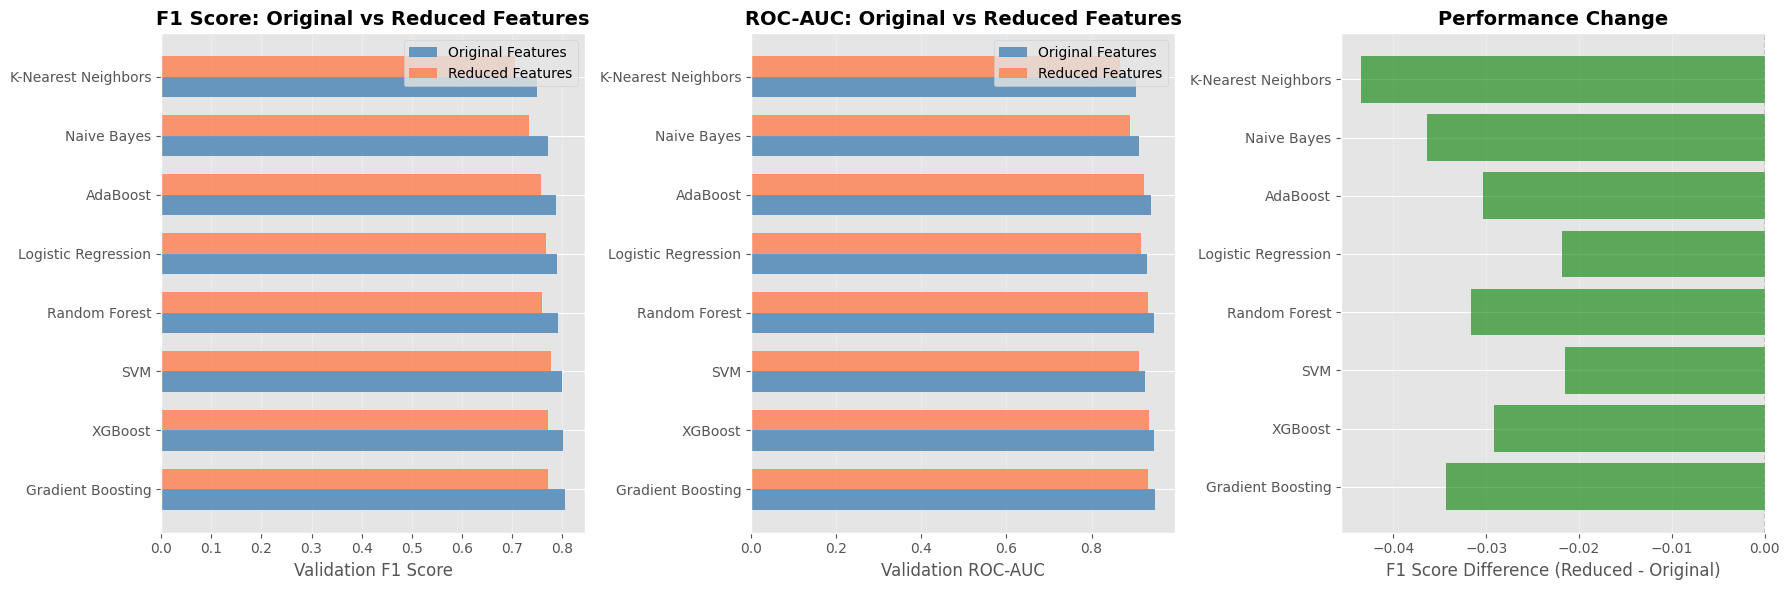


SUMMARY STATISTICS
Average F1 Score Change: -0.0311
Average ROC-AUC Change: -0.0181
Average Accuracy Change: -0.0173

Best model (original): Gradient Boosting (F1: 0.8054)
Best model (reduced): SVM (F1: 0.7788)


In [22]:
# Compare performance: Original vs Reduced Features
print("=" * 60)
print("PERFORMANCE COMPARISON: ORIGINAL vs REDUCED FEATURES")
print("=" * 60)

# Merge comparison dataframes
comparison_merged = comparison_df.merge(
    comparison_df_reduced,
    on='Model',
    suffixes=('_original', '_reduced')
)

# Calculate differences
comparison_merged['F1_diff'] = comparison_merged['Val F1_reduced'] - comparison_merged['Val F1_original']
comparison_merged['ROC_AUC_diff'] = comparison_merged['Val ROC-AUC_reduced'] - comparison_merged['Val ROC-AUC_original']
comparison_merged['Accuracy_diff'] = comparison_merged['Val Accuracy_reduced'] - comparison_merged['Val Accuracy_original']

print("\nPerformance Changes (Reduced - Original):")
print(comparison_merged[['Model', 'Val F1_original', 'Val F1_reduced', 'F1_diff',
                         'Val ROC-AUC_original', 'Val ROC-AUC_reduced', 'ROC_AUC_diff']].to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# F1 Score comparison
x_pos = np.arange(len(comparison_merged))
width = 0.35
axes[0].barh(x_pos - width/2, comparison_merged['Val F1_original'], width, 
             label='Original Features', color='steelblue', alpha=0.8)
axes[0].barh(x_pos + width/2, comparison_merged['Val F1_reduced'], width,
             label='Reduced Features', color='coral', alpha=0.8)
axes[0].set_yticks(x_pos)
axes[0].set_yticklabels(comparison_merged['Model'])
axes[0].set_xlabel('Validation F1 Score', fontsize=12)
axes[0].set_title('F1 Score: Original vs Reduced Features', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# ROC-AUC comparison
axes[1].barh(x_pos - width/2, comparison_merged['Val ROC-AUC_original'], width,
             label='Original Features', color='steelblue', alpha=0.8)
axes[1].barh(x_pos + width/2, comparison_merged['Val ROC-AUC_reduced'], width,
             label='Reduced Features', color='coral', alpha=0.8)
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(comparison_merged['Model'])
axes[1].set_xlabel('Validation ROC-AUC', fontsize=12)
axes[1].set_title('ROC-AUC: Original vs Reduced Features', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

# Performance difference
axes[2].barh(x_pos, comparison_merged['F1_diff'], color='green', alpha=0.6)
axes[2].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[2].set_yticks(x_pos)
axes[2].set_yticklabels(comparison_merged['Model'])
axes[2].set_xlabel('F1 Score Difference (Reduced - Original)', fontsize=12)
axes[2].set_title('Performance Change', fontsize=14, fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
print(f"Average F1 Score Change: {comparison_merged['F1_diff'].mean():.4f}")
print(f"Average ROC-AUC Change: {comparison_merged['ROC_AUC_diff'].mean():.4f}")
print(f"Average Accuracy Change: {comparison_merged['Accuracy_diff'].mean():.4f}")
print(f"\nBest model (original): {comparison_df.iloc[0]['Model']} (F1: {comparison_df.iloc[0]['Val F1']:.4f})")
print(f"Best model (reduced): {comparison_df_reduced.iloc[0]['Model']} (F1: {comparison_df_reduced.iloc[0]['Val F1']:.4f})")


In [23]:
# Select best model for reduced features
best_model_name_reduced = comparison_df_reduced.iloc[0]['Model']
best_model_reduced = trained_models_reduced[best_model_name_reduced]
best_metrics_reduced = results_reduced[best_model_name_reduced]

print("=" * 60)
print(f"BEST MODEL (REDUCED FEATURES): {best_model_name_reduced}")
print("=" * 60)
print(f"\nValidation Metrics:")
print(f"  Accuracy:  {best_metrics_reduced['val_accuracy']:.4f}")
print(f"  Precision: {best_metrics_reduced['val_precision']:.4f}")
print(f"  Recall:    {best_metrics_reduced['val_recall']:.4f}")
print(f"  F1 Score:  {best_metrics_reduced['val_f1']:.4f}")
print(f"  ROC-AUC:   {best_metrics_reduced['val_roc_auc']:.4f}")

# Evaluate on test set
if best_metrics_reduced['needs_scaling']:
    X_test_reduced_use = X_test_reduced_scaled
else:
    X_test_reduced_use = X_test_reduced

y_test_reduced_pred = best_model_reduced.predict(X_test_reduced_use)
y_test_reduced_proba = best_model_reduced.predict_proba(X_test_reduced_use)[:, 1]

test_accuracy_reduced = accuracy_score(y_test_reduced, y_test_reduced_pred)
test_precision_reduced = precision_score(y_test_reduced, y_test_reduced_pred, zero_division=0)
test_recall_reduced = recall_score(y_test_reduced, y_test_reduced_pred)
test_f1_reduced = f1_score(y_test_reduced, y_test_reduced_pred)
test_roc_auc_reduced = roc_auc_score(y_test_reduced, y_test_reduced_proba)

print(f"\nTest Metrics:")
print(f"  Accuracy:  {test_accuracy_reduced:.4f}")
print(f"  Precision: {test_precision_reduced:.4f}")
print(f"  Recall:    {test_recall_reduced:.4f}")
print(f"  F1 Score:  {test_f1_reduced:.4f}")
print(f"  ROC-AUC:   {test_roc_auc_reduced:.4f}")

# Compare with original best model
print("\n" + "=" * 60)
print("BEST MODEL COMPARISON")
print("=" * 60)
print(f"\nOriginal Best Model ({best_model_name}):")
print(f"  Validation F1:  {best_metrics['val_f1']:.4f}")
print(f"  Validation ROC-AUC: {best_metrics['val_roc_auc']:.4f}")
print(f"  Test F1:        {test_f1:.4f}")
print(f"  Test ROC-AUC:   {test_roc_auc:.4f}")

print(f"\nReduced Best Model ({best_model_name_reduced}):")
print(f"  Validation F1:  {best_metrics_reduced['val_f1']:.4f}")
print(f"  Validation ROC-AUC: {best_metrics_reduced['val_roc_auc']:.4f}")
print(f"  Test F1:        {test_f1_reduced:.4f}")
print(f"  Test ROC-AUC:   {test_roc_auc_reduced:.4f}")

print(f"\nPerformance Change:")
print(f"  Validation F1:  {best_metrics_reduced['val_f1'] - best_metrics['val_f1']:+.4f}")
print(f"  Validation ROC-AUC: {best_metrics_reduced['val_roc_auc'] - best_metrics['val_roc_auc']:+.4f}")
print(f"  Test F1:        {test_f1_reduced - test_f1:+.4f}")
print(f"  Test ROC-AUC:   {test_roc_auc_reduced - test_roc_auc:+.4f}")


BEST MODEL (REDUCED FEATURES): SVM

Validation Metrics:
  Accuracy:  0.8422
  Precision: 0.6913
  Recall:    0.8917
  F1 Score:  0.7788
  ROC-AUC:   0.9110

Test Metrics:
  Accuracy:  0.8481
  Precision: 0.7000
  Recall:    0.8971
  F1 Score:  0.7864
  ROC-AUC:   0.9149

BEST MODEL COMPARISON

Original Best Model (Gradient Boosting):
  Validation F1:  0.8054
  Validation ROC-AUC: 0.9482
  Test F1:        0.8132
  Test ROC-AUC:   0.9502

Reduced Best Model (SVM):
  Validation F1:  0.7788
  Validation ROC-AUC: 0.9110
  Test F1:        0.7864
  Test ROC-AUC:   0.9149

Performance Change:
  Validation F1:  -0.0266
  Validation ROC-AUC: -0.0373
  Test F1:        -0.0268
  Test ROC-AUC:   -0.0353


In [ ]:
# Feature Importance for Reduced Feature Set
# Check models in order of performance until we find one that supports feature importance
print("=" * 60)
print("FEATURE IMPORTANCE (REDUCED FEATURE SET)")
print("=" * 60)

feature_importance_reduced = None
model_for_importance = None
model_name_for_importance = None

# Iterate through models in order of performance
for idx, row in comparison_df_reduced.iterrows():
    model_name = row['Model']
    model = trained_models_reduced[model_name]
    
    if hasattr(model, 'feature_importances_'):
        feature_importance_reduced = pd.DataFrame({
            'feature': X_reduced.columns,
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False)
        model_for_importance = model
        model_name_for_importance = model_name
        break
    elif hasattr(model, 'coef_'):
        feature_importance_reduced = pd.DataFrame({
            'feature': X_reduced.columns,
            'coefficient': model.coef_[0]
        }).sort_values('coefficient', key=abs, ascending=False)
        model_for_importance = model
        model_name_for_importance = model_name
        break

if feature_importance_reduced is not None:
    if hasattr(model_for_importance, 'feature_importances_'):
        print(f"\nUsing {model_name_for_importance} for feature importance (best model: {best_model_name_reduced})")
        print(f"\nTop 20 Most Important Features ({model_name_for_importance}):")
        print(feature_importance_reduced.head(20).to_string(index=False))
        
        # Visualize top features
        plt.figure(figsize=(10, 8))
        top_features_reduced = feature_importance_reduced.head(20)
        plt.barh(range(len(top_features_reduced)), top_features_reduced['importance'], color='coral')
        plt.yticks(range(len(top_features_reduced)), top_features_reduced['feature'])
        plt.xlabel('Importance', fontsize=12)
        plt.title(f'Top 20 Feature Importance ({model_name_for_importance}) - Reduced Features', fontsize=14, fontweight='bold')
        plt.gca().invert_yaxis()
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
    elif hasattr(model_for_importance, 'coef_'):
        print(f"\nUsing {model_name_for_importance} for feature importance (best model: {best_model_name_reduced})")
        print(f"\nTop 20 Most Important Features ({model_name_for_importance} - Coefficients):")
        print(feature_importance_reduced.head(20).to_string(index=False))
        
        # Visualize top features
        plt.figure(figsize=(10, 8))
        top_features_reduced = feature_importance_reduced.head(20)
        colors = ['red' if x < 0 else 'green' for x in top_features_reduced['coefficient']]
        plt.barh(range(len(top_features_reduced)), top_features_reduced['coefficient'], color=colors)
        plt.yticks(range(len(top_features_reduced)), top_features_reduced['feature'])
        plt.xlabel('Coefficient', fontsize=12)
        plt.title(f'Top 20 Feature Coefficients ({model_name_for_importance}) - Reduced Features', fontsize=14, fontweight='bold')
        plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
        plt.gca().invert_yaxis()
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print(f"None of the trained models support feature importance extraction.")


FEATURE IMPORTANCE (REDUCED FEATURE SET)
Model SVM does not support feature importance extraction.


In [ ]:
# Permutation Importance for Reduced Feature Set
from sklearn.inspection import permutation_importance

print("\n" + "=" * 60)
print("PERMUTATION IMPORTANCE (REDUCED FEATURES - Validation)")
print("=" * 60)

# Use the same model that was used for feature importance (or best model if feature importance wasn't available)
if model_for_importance is not None:
    model_for_perm = model_for_importance
    model_name_for_perm = model_name_for_importance
    # Determine if model needs scaled data
    needs_scaling_perm = results_reduced[model_name_for_perm]['needs_scaling']
else:
    model_for_perm = best_model_reduced
    model_name_for_perm = best_model_name_reduced
    needs_scaling_perm = best_metrics_reduced['needs_scaling']

if model_for_importance is not None:
    print(f"Using {model_name_for_perm} for permutation importance (same as feature importance)")

# Compute permutation importance on validation set
perm_importance_reduced = permutation_importance(
    model_for_perm,
    X_val_reduced if not needs_scaling_perm else X_val_reduced_scaled,
    y_val_reduced,
    n_repeats=10,
    random_state=42,
    scoring='f1',
    n_jobs=-1
)

# Create DataFrame
perm_importance_df_reduced = pd.DataFrame({
    'feature': X_reduced.columns,
    'importance_mean': perm_importance_reduced.importances_mean,
    'importance_std': perm_importance_reduced.importances_std
}).sort_values('importance_mean', ascending=False)

print("\nTop 20 Features by Permutation Importance (Reduced Features):")
print(perm_importance_df_reduced.head(20).to_string(index=False))

# Visualize comparison: Original vs Reduced
# Check if we have feature importance for both original and reduced models
has_original_importance = hasattr(best_model, 'feature_importances_') or hasattr(best_model, 'coef_')
has_reduced_importance = model_for_importance is not None

if has_original_importance and has_reduced_importance:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Original features - top 20
    top_perm_original = perm_importance_df.head(20)
    axes[0].barh(range(len(top_perm_original)), top_perm_original['importance_mean'],
                 xerr=top_perm_original['importance_std'], color='steelblue', capsize=3)
    axes[0].set_yticks(range(len(top_perm_original)))
    axes[0].set_yticklabels(top_perm_original['feature'])
    axes[0].set_xlabel('Importance (Mean ± Std)', fontsize=12)
    axes[0].set_title('Permutation Importance (Original Features)', fontsize=14, fontweight='bold')
    axes[0].invert_yaxis()
    axes[0].grid(axis='x', alpha=0.3)
    
    # Reduced features - top 20
    top_perm_reduced = perm_importance_df_reduced.head(20)
    axes[1].barh(range(len(top_perm_reduced)), top_perm_reduced['importance_mean'],
                 xerr=top_perm_reduced['importance_std'], color='coral', capsize=3)
    axes[1].set_yticks(range(len(top_perm_reduced)))
    axes[1].set_yticklabels(top_perm_reduced['feature'])
    axes[1].set_xlabel('Importance (Mean ± Std)', fontsize=12)
    axes[1].set_title('Permutation Importance (Reduced Features)', fontsize=14, fontweight='bold')
    axes[1].invert_yaxis()
    axes[1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Compare top features
    print("\n" + "=" * 60)
    print("TOP FEATURES COMPARISON")
    print("=" * 60)
    print("\nTop 10 Features (Original):")
    print(perm_importance_df.head(10)[['feature', 'importance_mean']].to_string(index=False))
    print("\nTop 10 Features (Reduced):")
    print(perm_importance_df_reduced.head(10)[['feature', 'importance_mean']].to_string(index=False))
    
    # Find features that moved up in ranking
    print("\n" + "=" * 60)
    print("FEATURES THAT GAINED IMPORTANCE")
    print("=" * 60)
    
    # Get features that exist in both sets
    common_features = set(X.columns) & set(X_reduced.columns)
    
    # Create ranking comparison
    rank_comparison = []
    for feat in common_features:
        orig_rank = perm_importance_df[perm_importance_df['feature'] == feat].index[0] + 1 if feat in perm_importance_df['feature'].values else None
        reduced_rank = perm_importance_df_reduced[perm_importance_df_reduced['feature'] == feat].index[0] + 1 if feat in perm_importance_df_reduced['feature'].values else None
        
        if orig_rank is not None and reduced_rank is not None:
            rank_improvement = orig_rank - reduced_rank  # Positive means improved (lower rank number = better)
            rank_comparison.append({
                'feature': feat,
                'original_rank': orig_rank,
                'reduced_rank': reduced_rank,
                'rank_improvement': rank_improvement,
                'original_importance': perm_importance_df[perm_importance_df['feature'] == feat]['importance_mean'].values[0],
                'reduced_importance': perm_importance_df_reduced[perm_importance_df_reduced['feature'] == feat]['importance_mean'].values[0]
            })
    
    rank_comparison_df = pd.DataFrame(rank_comparison).sort_values('rank_improvement', ascending=False)
    
    print("\nTop 10 Features with Largest Rank Improvement:")
    print(rank_comparison_df.head(10)[['feature', 'original_rank', 'reduced_rank', 'rank_improvement']].to_string(index=False))



PERMUTATION IMPORTANCE (REDUCED FEATURES - Validation)

Top 20 Features by Permutation Importance (Reduced Features):
                      feature  importance_mean  importance_std
              num_assessments         0.396225        0.009040
         first_assessment_day         0.025526        0.002164
            presentation_year         0.005650        0.002096
presentation_semester_encoded         0.005448        0.002770
         avg_assessment_score         0.005138        0.001244
                first_vle_day         0.004757        0.002392
         vle_interaction_days         0.003910        0.001606
              registered_late         0.003525        0.001063
             registered_early         0.002873        0.000753
       num_banked_assessments         0.002707        0.000718
             total_vle_clicks         0.002309        0.000810
         max_assessment_score         0.002141        0.001268
   module_presentation_length         0.001414        0.000994

## 11. Summary



PERMUTATION IMPORTANCE (Validation)
(More robust than tree-based importance - validates feature rankings)

Top 20 Features by Permutation Importance:
                   feature  importance_mean  importance_std
              last_vle_day         0.411202        0.009268
       last_assessment_day         0.025645        0.004731
      vle_interaction_days         0.012159        0.002517
           studied_credits         0.009970        0.001641
           num_assessments         0.008849        0.002190
          total_vle_clicks         0.004870        0.001333
      max_assessment_score         0.004083        0.001509
         presentation_year         0.003479        0.001569
module_presentation_length         0.003460        0.002338
      min_assessment_score         0.003215        0.001082
      first_assessment_day         0.003112        0.001283
             first_vle_day         0.002170        0.001317
            gender_encoded         0.001917        0.001243
         

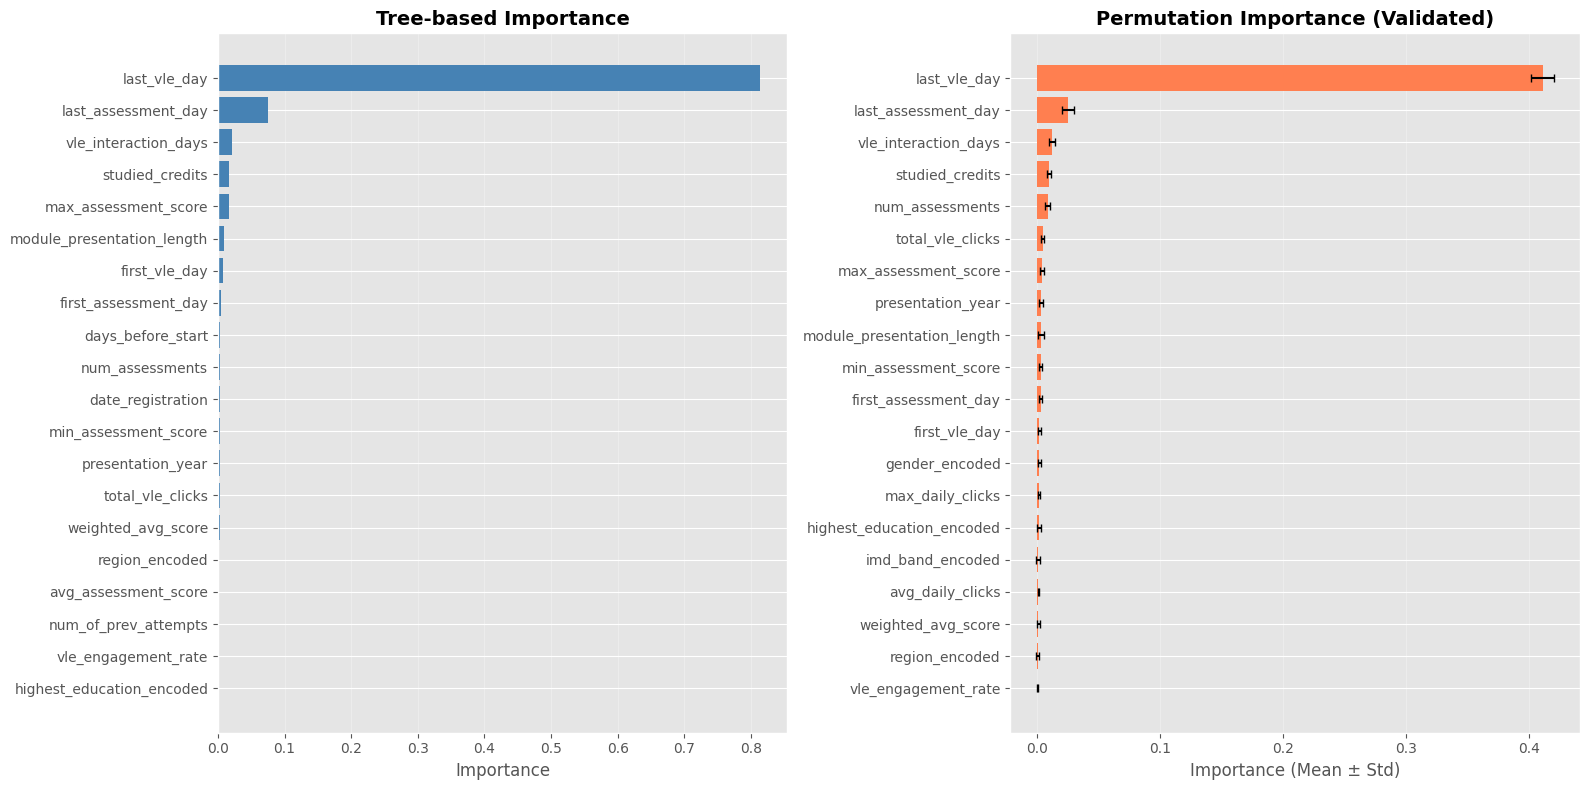


RANKING COMPARISON

Top 10 features with largest ranking differences:
                   feature  tree_rank  perm_rank  rank_diff
      num_of_prev_attempts          1          1          0
           studied_credits          2          2          0
         date_registration          3          3          0
          registered_early          4          4          0
           registered_late          5          5          0
         days_before_start          6          6          0
          days_after_start          7          7          0
module_presentation_length          8          8          0
      avg_assessment_score          9          9          0
      min_assessment_score         10         10          0


In [26]:
# Add Permutation Importance (more robust than tree-based importance)
from sklearn.inspection import permutation_importance

print("\n" + "=" * 60)
print("PERMUTATION IMPORTANCE (Validation)")
print("=" * 60)
print("(More robust than tree-based importance - validates feature rankings)")

# Determine task type and scoring metric
task_type = 'classification'  # This is a classification task
scoring_metric = 'f1' if task_type == 'classification' else 'r2'

# Compute permutation importance on validation set
perm_importance = permutation_importance(
    best_model,
    X_val,
    y_val,
    n_repeats=10,
    random_state=42,
    scoring=scoring_metric,
    n_jobs=-1
)

# Create DataFrame
perm_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print("\nTop 20 Features by Permutation Importance:")
print(perm_importance_df.head(20).to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Tree-based importance (if available)
if hasattr(best_model, 'feature_importances_'):
    top_tree = feature_importance.head(20)
    axes[0].barh(range(len(top_tree)), top_tree['importance'], color='steelblue')
    axes[0].set_yticks(range(len(top_tree)))
    axes[0].set_yticklabels(top_tree['feature'])
    axes[0].set_xlabel('Importance', fontsize=12)
    axes[0].set_title('Tree-based Importance', fontsize=14, fontweight='bold')
    axes[0].invert_yaxis()
    axes[0].grid(axis='x', alpha=0.3)

# Permutation importance
top_perm = perm_importance_df.head(20)
axes[1].barh(range(len(top_perm)), top_perm['importance_mean'],
             xerr=top_perm['importance_std'], color='coral', capsize=3)
axes[1].set_yticks(range(len(top_perm)))
axes[1].set_yticklabels(top_perm['feature'])
axes[1].set_xlabel('Importance (Mean ± Std)', fontsize=12)
axes[1].set_title('Permutation Importance (Validated)', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Compare rankings
print("\n" + "=" * 60)
print("RANKING COMPARISON")
print("=" * 60)
if hasattr(best_model, 'feature_importances_'):
    comparison = pd.DataFrame({
        'feature': X.columns,
        'tree_rank': feature_importance.reset_index(drop=True).index + 1,
        'perm_rank': perm_importance_df.reset_index(drop=True).index + 1
    })
    comparison['rank_diff'] = abs(comparison['tree_rank'] - comparison['perm_rank'])
    print("\nTop 10 features with largest ranking differences:")
    print(comparison.nlargest(10, 'rank_diff')[['feature', 'tree_rank', 'perm_rank', 'rank_diff']].to_string(index=False))
elif hasattr(best_model, 'coef_'):
    # For linear models, compare coefficient-based ranking
    coef_importance = pd.DataFrame({
        'feature': X.columns,
        'coef_abs': np.abs(best_model.coef_[0])
    }).sort_values('coef_abs', ascending=False)
    
    comparison = pd.DataFrame({
        'feature': X.columns,
        'coef_rank': coef_importance.reset_index(drop=True).index + 1,
        'perm_rank': perm_importance_df.reset_index(drop=True).index + 1
    })
    comparison['rank_diff'] = abs(comparison['coef_rank'] - comparison['perm_rank'])
    print("\nTop 10 features with largest ranking differences:")
    print(comparison.nlargest(10, 'rank_diff')[['feature', 'coef_rank', 'perm_rank', 'rank_diff']].to_string(index=False))


In [27]:
print("=" * 60)
print("MODEL TRAINING SUMMARY (WITHOUT DATA LEAKAGE)")
print("=" * 60)
print(f"\nTotal models trained: {len(models)}")
print(f"Best model: {best_model_name}")
print(f"\nExcluded leakage features:")
print("  - has_unregistration")
print("  - date_unregistration")
print("  - days_until_unregistration")
print(f"\nBest Model Performance:")
print(f"  Validation F1:  {best_metrics['val_f1']:.4f}")
print(f"  Validation ROC-AUC: {best_metrics['val_roc_auc']:.4f}")
print(f"  Test F1:        {test_f1:.4f}")
print(f"  Test ROC-AUC:   {test_roc_auc:.4f}")
print(f"\nModel saved to: models/best_dropout_model_no_leakage.pkl")
print(f"\n✓ Training complete!")
print(f"\nNote: This model provides realistic performance metrics")
print(f"      that would be achievable in a real-world early warning system.")


MODEL TRAINING SUMMARY (WITHOUT DATA LEAKAGE)

Total models trained: 8
Best model: Gradient Boosting

Excluded leakage features:
  - has_unregistration
  - date_unregistration
  - days_until_unregistration

Best Model Performance:
  Validation F1:  0.8054
  Validation ROC-AUC: 0.9482
  Test F1:        0.8132
  Test ROC-AUC:   0.9502

Model saved to: models/best_dropout_model_no_leakage.pkl

✓ Training complete!

Note: This model provides realistic performance metrics
      that would be achievable in a real-world early warning system.
